In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys

In [2]:
file10 = uproot.open("use10.root")
dir10= file10["ntuples"]    
tree10 = dir10["outT"]


file100 = uproot.open("use100.root")
dir100= file100["ntuples"]    
tree100 = dir100["outT"]

file1000 = uproot.open("file1000.root")
dir1000= file1000["ntuples"]    
tree1000 = dir1000["outT"]

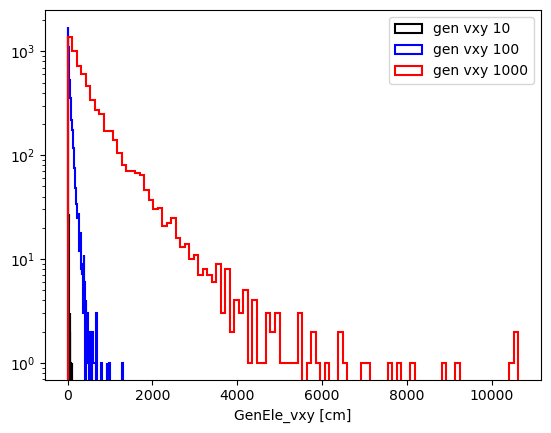

In [3]:
genelevxy10 = tree10["GenEle_vxy"].array()
genelevxy100 = tree100["GenEle_vxy"].array()
genelevxy1000 = tree1000["GenEle_vxy"].array()

plt.hist(genelevxy10, bins=100,histtype="step",color = 'black',linewidth=1.5, label="gen vxy 10")
plt.hist(genelevxy100, bins=100,histtype="step",color = 'blue',linewidth=1.5, label="gen vxy 100")
plt.hist(genelevxy1000, bins=100,histtype="step",color = 'red', linewidth=1.5, label="gen vxy 1000")


plt.yscale("log")
plt.xlabel("GenEle_vxy [cm]")
plt.legend()
plt.show()

In [4]:
pdgs10 = tree10["GenPart_ID"].array()
mask10 = pdgs10==1000023

pdgs100 = tree100["GenPart_ID"].array()
mask100 = pdgs100==1000023

pdgs1000 = tree1000["GenPart_ID"].array()
mask1000 = pdgs1000==1000023


In [5]:
energy10 = tree10["GenPart_e"].array()
energychi210=energy10[mask10]

mass10 = tree10["GenPart_mass"].array()
mchi210 = mass10[mask10]


energy100 = tree100["GenPart_e"].array()
energychi2100=energy100[mask100]

mass100 = tree100["GenPart_mass"].array()
mchi2100 = mass100[mask100]


energy1000 = tree1000["GenPart_e"].array()
energychi21000=energy1000[mask1000]

mass1000 = tree1000["GenPart_mass"].array()
mchi21000 = mass1000[mask1000]


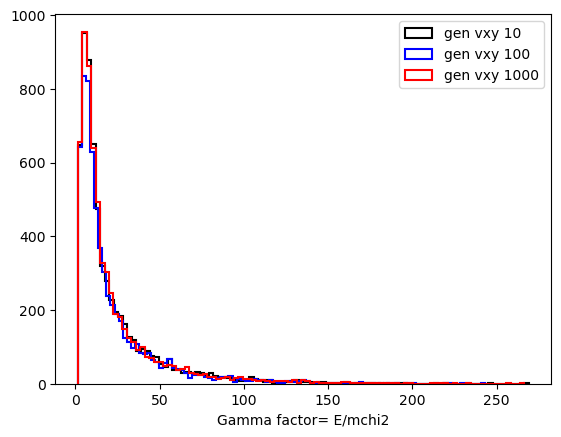

In [6]:
gamma10= energychi210/mchi210
gamma100= energychi2100/mchi2100
gamma1000= energychi21000/mchi21000

#plt.hist(gamma)
plt.hist(gamma10, bins=100, histtype="step",color = 'black',linewidth=1.5, label="gen vxy 10")

plt.hist(gamma100, bins=100, histtype="step",color = 'blue',linewidth=1.5, label="gen vxy 100")
plt.hist(gamma1000, bins=100, histtype="step",color = 'red',linewidth=1.5, label="gen vxy 1000")

plt.xlabel("Gamma factor= E/mchi2")
plt.legend()
plt.show()

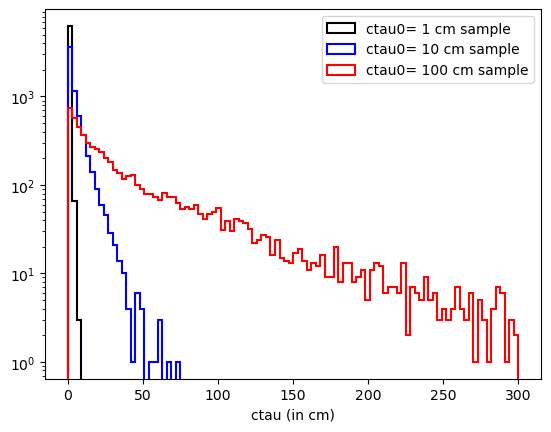

In [8]:
ctau10= genelevxy10/gamma10

ctau100= genelevxy100/gamma100
ctau1000= genelevxy1000/gamma1000

plt.hist(ctau10, bins=100, histtype="step",linewidth=1.5, range=(0,300),density=False, log=True, color = 'black', label="ctau0= 1 cm sample")

plt.hist(ctau100, bins=100, histtype="step",linewidth=1.5, range=(0,300),density=False, log=True, color = 'blue', label="ctau0= 10 cm sample")
plt.hist(ctau1000, bins=100, histtype="step",linewidth=1.5,range=(0,300),density=False,log=True, color = 'red', label="ctau0= 100 cm sample")

plt.xlabel("ctau (in cm)")
plt.legend()
plt.savefig("ctaucompare.png", dpi=300)
plt.show()
